# Retail Customer Segmentation

### NextGen 3MTT Data Science Capstone — DS 02

**Objective:** Segment retail customers based on purchasing behaviour using RFM analysis and K-Means clustering.

**Tools:** Python, Pandas, Scikit-learn, Matplotlib, Jupyter/Google Colab

## 1. Project Overview

Retail businesses often serve customers with very different purchasing behaviours. However, treating all customers as a single group can result in ineffective marketing, customer retention, and loyalty strategies.

This project develops a customer segmentation MVP for a POS/retail business. The solution uses transaction data to identify groups of customers with similar purchasing behaviours.

RFM analysis is used to describe customers based on Recency, Frequency, and Monetary value, while K-Means clustering is used to identify customer segments.

## 2. Problem Context

Many retailers in Nigeria, particularly small and medium-sized businesses, rely on transaction records without fully using them to understand differences between customers.

A retailer may have frequent high-spending customers, occasional customers, and customers who have stopped purchasing. Treating these groups in the same way can result in missed opportunities for customer retention and revenue growth.

This project demonstrates how transaction data can be transformed into actionable customer segments that can support more targeted business decisions.

## 3. Project Objectives

The project aims to:

1. Prepare and clean retail transaction data for analysis.
2. Construct customer-level RFM features.
3. Apply K-Means clustering to identify customer groups.
4. Evaluate the quality of the clustering results.
5. Profile the identified customer segments.
6. Estimate the revenue contribution of each segment.
7. Provide practical strategies for managing different customer groups.

## 4. Dataset

The project uses the Online Retail Dataset obtained from Kaggle.

The dataset contains retail transaction records including invoice number, product description, quantity, invoice date, unit price, customer identifier, and country.

The raw dataset contains **541,909 transaction records**.

For this project, the data is used to demonstrate a customer segmentation workflow applicable to POS/retail businesses.

In [66]:
#PIP installing Kaggle to get data access
!pip install -q kagglehub

In [67]:
# Importing required libraries
import os
import joblib
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [68]:
# Download the dataset from Kaggle
path = kagglehub.dataset_download(
    "ulrikthygepedersen/online-retail-dataset"
)

print(path)

Using Colab cache for faster access to the 'online-retail-dataset' dataset.
/kaggle/input/online-retail-dataset


In [69]:
# Inspect downloaded files
os.listdir(path)

['.nfs0000000033c2c43e00000028', 'online_retail.csv']

In [70]:
# Define the dataset path
file_path = os.path.join(path, "online_retail.csv")

# Load the dataset
df = pd.read_csv(file_path)

print(f"Dataset loaded: {df.shape[0]:,} rows and {df.shape[1]} columns")

Dataset loaded: 541,909 rows and 8 columns


## 5. Data Preparation

The transaction data was inspected for missing values, duplicate records, cancelled transactions, and invalid quantities or prices before customer-level analysis.

In [71]:
# Inspect dataset dimensions
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 541,909
Columns: 8


In [72]:
# Review column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [73]:
# Summarize missing values by column
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (missing_values / len(df) * 100).round(2)
})

missing_summary[missing_summary["Missing Values"] > 0]

,Missing Values,Missing Percentage
Description,1454,0.27
CustomerID,135080,24.93


In [74]:
# Review transaction quantity and price distributions
df[["Quantity", "UnitPrice"]].describe()

,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


In [75]:
# Count duplicate records
duplicate_count = df.duplicated().sum()

print(f"Duplicate records: {duplicate_count:,}")

Duplicate records: 5,268


In [76]:
# Review numerical variables
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## 6. Data Cleaning

The dataset was cleaned to ensure that the transactions used for customer segmentation represented valid purchasing activity.

Records without a `CustomerID` were excluded because customer identification is required for RFM analysis. Exact duplicate records were removed to prevent repeated transactions from influencing customer behaviour measures. Transactions with non-positive quantities or unit prices were also excluded because they do not represent valid positive sales.

Missing product descriptions were retained because product descriptions are not required for the RFM features used in customer segmentation.

In [77]:
# Create a copy for preprocessing
clean_df = df.copy()

In [78]:
# Remove cancelled invoices
clean_df = clean_df[
    ~clean_df["InvoiceNo"].astype(str).str.startswith("C")
]

In [79]:
# Retain transactions with identifiable customers
clean_df = clean_df[
    clean_df["CustomerID"].notna()
]

In [80]:
# Retain valid sales quantities and prices
clean_df = clean_df[
    (clean_df["Quantity"] > 0) &
    (clean_df["UnitPrice"] > 0)
]

In [81]:
# Remove exact duplicate transactions
clean_df = clean_df.drop_duplicates()

In [82]:
# Calculate transaction value
clean_df["TotalAmount"] = (
    clean_df["Quantity"] * clean_df["UnitPrice"]
)

In [83]:
# Review the cleaned dataset
print(f"Rows after cleaning: {len(clean_df):,}")
print(f"Customers: {clean_df['CustomerID'].nunique():,}")
print(f"Transactions: {clean_df['InvoiceNo'].nunique():,}")

Rows after cleaning: 392,692
Customers: 4,338
Transactions: 18,532


## 7. Data Cleaning Summary

The cleaning process reduced the dataset from 541,909 raw transaction records to 392,692 valid transaction records. The resulting dataset contains 4,338 identifiable customers and 18,532 unique invoices.

The reduction primarily resulted from excluding transactions without customer identifiers, cancelled transactions, invalid quantities or prices, and duplicate records.

In [84]:
# Summarize the cleaned dataset
cleaning_summary = pd.DataFrame({
    "Measure": [
        "Raw Records",
        "Cleaned Records",
        "Records Removed",
        "Customers",
        "Unique Invoices"
    ],
    "Value": [
        len(df),
        len(clean_df),
        len(df) - len(clean_df),
        clean_df["CustomerID"].nunique(),
        clean_df["InvoiceNo"].nunique()
    ]
})

cleaning_summary

,Measure,Value
0,Raw Records,541909
1,Cleaned Records,392692
2,Records Removed,149217
3,Customers,4338
4,Unique Invoices,18532


## 8. Exploratory Data Analysis

Exploratory data analysis was conducted on the cleaned transaction data to understand purchasing patterns and identify characteristics that could influence customer segmentation. The analysis focuses on transaction value, quantity, and customer purchasing behaviour before constructing the RFM features.

In [85]:
# Review cleaned transaction statistics
clean_df[["Quantity", "UnitPrice", "TotalAmount"]].describe()

,Quantity,UnitPrice,TotalAmount
count,392692.000000,392692.000000,392692.000000
mean,13.119702,3.125914,22.631500
std,180.492832,22.241836,311.099224
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.450000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


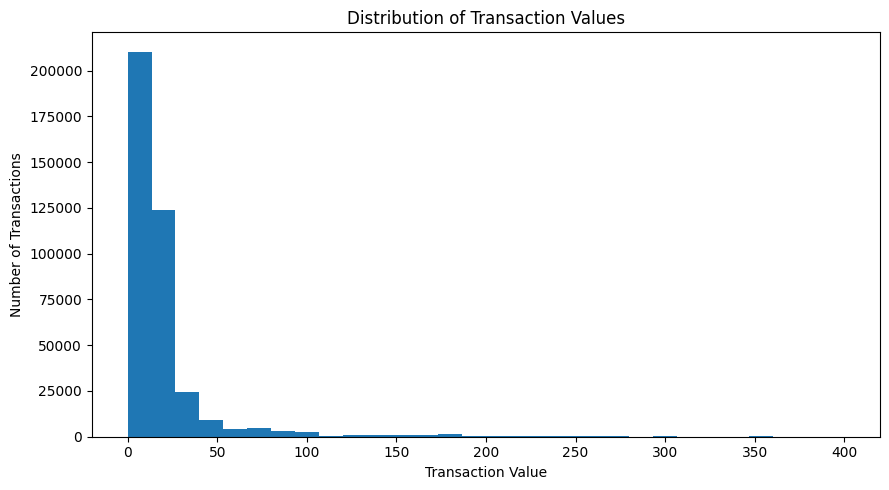

In [86]:
# Examine the distribution of transaction values
plt.figure(figsize=(9, 5))

plt.hist(
    clean_df["TotalAmount"],
    bins=30,
    range=(0, 400)
)

plt.xlabel("Transaction Value")
plt.ylabel("Number of Transactions")
plt.title("Distribution of Transaction Values")

plt.tight_layout()
plt.show()

In [87]:
# Calculate total spending for each customer
customer_spending = (
    clean_df.groupby("CustomerID")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

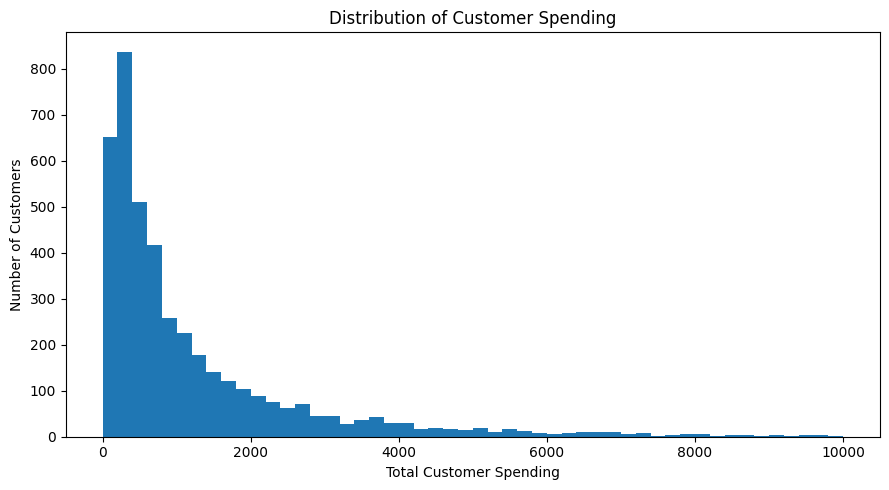

In [88]:
# Examine customer spending distribution
plt.figure(figsize=(9, 5))

plt.hist(
    customer_spending,
    bins=50,
    range=(0, 10000)
)

plt.xlabel("Total Customer Spending")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Spending")

plt.tight_layout()
plt.show()


## 9. RFM Feature Engineering

RFM analysis was used to transform transaction-level data into customer-level behavioural features.

- **Recency:** Number of days since the customer's most recent purchase.
- **Frequency:** Number of unique invoices associated with the customer.
- **Monetary:** Total amount spent by the customer.

These three features provide a concise representation of customer purchasing behaviour and are used as inputs for clustering.

In [89]:
# Convert transaction dates to datetime
clean_df["InvoiceDate"] = pd.to_datetime(clean_df["InvoiceDate"])

In [90]:
# DS-02: RFM Segment Profile

# Establish the reference date for recency calculation
reference_date = clean_df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [91]:
# Generate customer-level RFM features
rfm = clean_df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalAmount", "sum")
).reset_index()

In [92]:
# Review the resulting RFM dataset
print(f"Customers: {len(rfm):,}")
rfm.head()

Customers: 4,338


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [93]:
# Review RFM feature distributions
rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


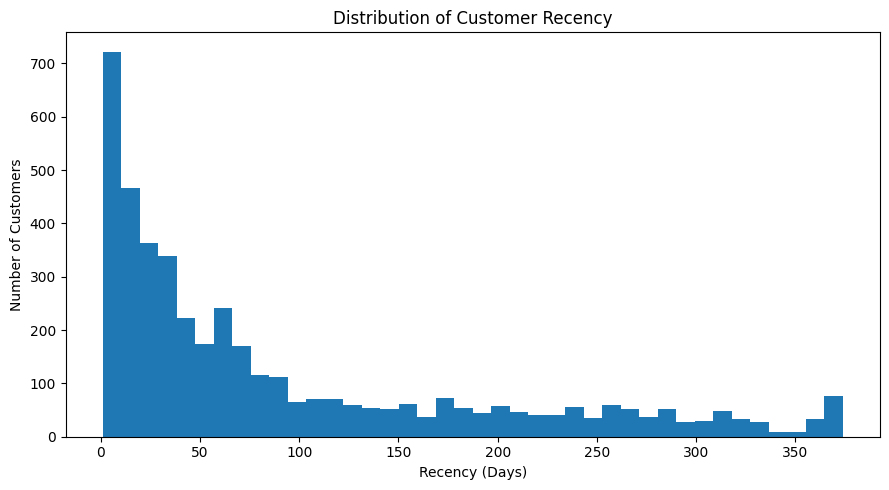

In [94]:
# Examine recency distribution
plt.figure(figsize=(9, 5))

plt.hist(
    rfm["Recency"],
    bins=40
)

plt.xlabel("Recency (Days)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Recency")

plt.tight_layout()
plt.show()

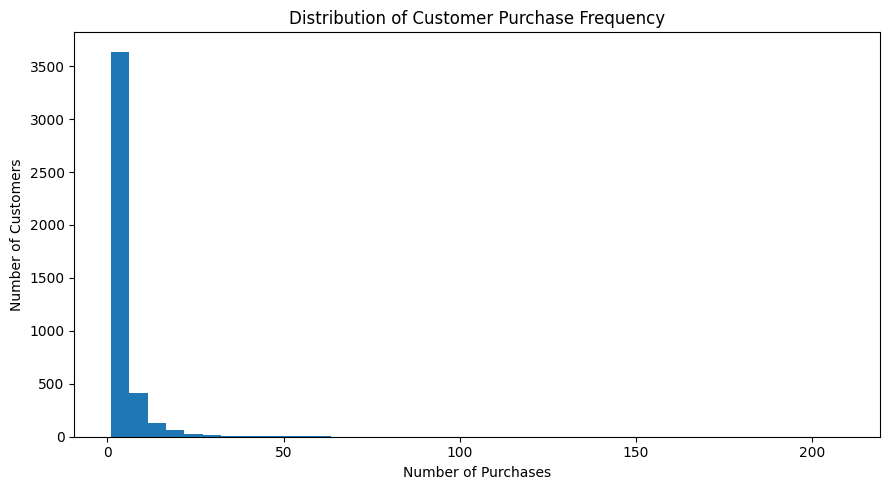

In [95]:
# Examine purchase frequency distribution
plt.figure(figsize=(9, 5))

plt.hist(
    rfm["Frequency"],
    bins=40
)

plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Purchase Frequency")

plt.tight_layout()
plt.show()

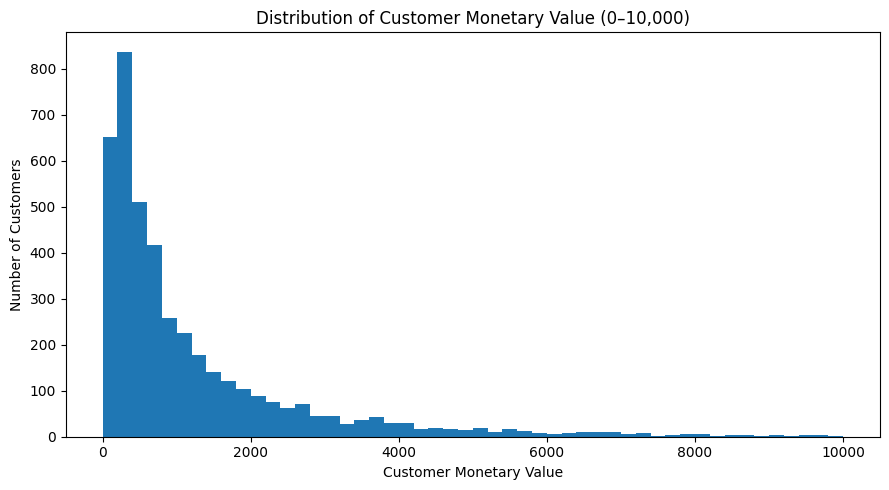

In [96]:
# Examine customer monetary value distribution
plt.figure(figsize=(9, 5))

plt.hist(
    rfm["Monetary"],
    bins=50,
    range=(0, 10000)
)

plt.xlabel("Customer Monetary Value")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Monetary Value (0–10,000)")

plt.tight_layout()
plt.show()

## 10. Feature Standardization

The RFM variables were standardized before clustering so that differences in their numerical scales would not cause one feature to disproportionately influence the distance calculations used by K-Means.

In [97]:
# Standardize RFM features
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[["Recency", "Frequency", "Monetary"]]
)

## 11. Customer Clustering

K-Means clustering was selected to group customers with similar RFM characteristics.

Different values of K were evaluated using the Silhouette Score. Five clusters were selected for the final customer segmentation based on the resulting cluster structure and its usefulness for distinguishing meaningful customer groups.

In [98]:
# Evaluate clustering performance across different cluster sizes
k_values = range(2, 11)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)

    print(f"K = {k}: Silhouette Score = {score:.4f}")

K = 2: Silhouette Score = 0.8958
K = 3: Silhouette Score = 0.5942
K = 4: Silhouette Score = 0.6162
K = 5: Silhouette Score = 0.6165
K = 6: Silhouette Score = 0.5983
K = 7: Silhouette Score = 0.5165
K = 8: Silhouette Score = 0.4859
K = 9: Silhouette Score = 0.4784
K = 10: Silhouette Score = 0.4792


## 12. Customer Clustering

K-Means clustering was selected to group customers with similar RFM characteristics.

Different values of K were evaluated using the Silhouette Score. Five clusters were selected for the final customer segmentation based on the resulting cluster structure and its usefulness for distinguishing meaningful customer groups.

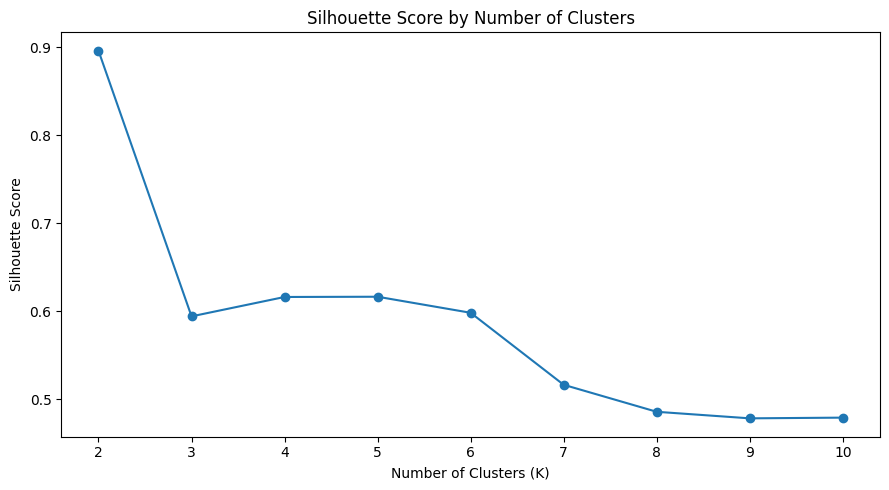

In [99]:
# Visualize silhouette scores
plt.figure(figsize=(9, 5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.xticks(k_values)

plt.tight_layout()
plt.show()

In [100]:
# Fit the final K-Means model
final_kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = final_kmeans.fit_predict(rfm_scaled)

In [101]:
# Evaluate the final clustering
final_silhouette = silhouette_score(
    rfm_scaled,
    rfm["Cluster"]
)

print(f"Final Silhouette Score: {final_silhouette:.4f}")

Final Silhouette Score: 0.6165


In [102]:
# Count customers in each cluster
cluster_counts = (
    rfm["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_counts

,count
Cluster,
0,3048
1,1063
2,8
3,213
4,6


In [103]:
# Calculate the percentage of customers in each cluster
cluster_percentages = (
    rfm["Cluster"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

cluster_percentages

,proportion
Cluster,
0,70.26
1,24.50
2,0.18
3,4.91
4,0.14


In [104]:
# Summarize RFM characteristics by cluster
cluster_profile = (
    rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]]
    .agg(["mean", "median"])
    .round(2)
)

cluster_profile

Recency        Frequency          Monetary           
           mean median      mean median       mean     median
Cluster                                                      
0         43.92   33.0      3.65    3.0    1333.13     818.58
1        248.47  243.0      1.55    1.0     478.65     310.05
2          6.50    1.5    120.50   95.0   55099.49   49640.96
3         15.67    6.0     21.29   18.0   12813.94    7834.65
4          7.67    5.0     42.83   50.5  190808.54  181431.64

In [105]:
# Create cluster-level summary
cluster_summary = (
    rfm.groupby("Cluster")
    .agg(
        Customers=("CustomerID", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean")
    )
    .round(2)
)

cluster_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,3048,43.92,3.65,1333.13
1,1063,248.47,1.55,478.65
2,8,6.50,120.50,55099.49
3,213,15.67,21.29,12813.94
4,6,7.67,42.83,190808.54


## 13. Customer Segment Profiles

The clusters were examined using their average Recency, Frequency, and Monetary values. Based on these behavioural characteristics, business-oriented names were assigned to the clusters.

In [106]:
# Assign business-oriented segment names
segment_names = {
    0: "Regular Customers",
    1: "At-Risk / Inactive Customers",
    2: "VIP Loyal Customers",
    3: "High-Value Loyal Customers",
    4: "Elite VIP Customers"
}

rfm["Segment"] = rfm["Cluster"].map(segment_names)

In [107]:
# Save customer segmentation results
rfm.to_csv("customer_segments.csv", index=False)

In [108]:
# Summarize customer segments
segment_summary = (
    rfm.groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean")
    )
    .round(2)
)

segment_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
At-Risk / Inactive Customers,1063,248.47,1.55,478.65
Elite VIP Customers,6,7.67,42.83,190808.54
High-Value Loyal Customers,213,15.67,21.29,12813.94
Regular Customers,3048,43.92,3.65,1333.13
VIP Loyal Customers,8,6.50,120.50,55099.49


## 14. Customer Segment Profiles

The clusters were examined using their average Recency, Frequency, and Monetary values. Based on these behavioural characteristics, business-oriented names were assigned to the clusters.

## Customer Segment and Revenue Analysis

The customer segments were evaluated based on their size and contribution to total revenue. This provides a business perspective on the clustering results and helps identify segments that generate disproportionate revenue.

In [109]:
# Summarize customer distribution by segment
segment_distribution = (
    rfm.groupby("Segment")
    .agg(Customers=("CustomerID", "count"))
)

segment_distribution["Customer_Share_%"] = (
    segment_distribution["Customers"]
    / len(rfm) * 100
).round(2)

segment_distribution

,Customers,Customer_Share_%
Segment,,
At-Risk / Inactive Customers,1063,24.50
Elite VIP Customers,6,0.14
High-Value Loyal Customers,213,4.91
Regular Customers,3048,70.26
VIP Loyal Customers,8,0.18


In [110]:
# Calculate total revenue generated by each customer
customer_revenue = (
    clean_df.groupby("CustomerID")["TotalAmount"]
    .sum()
    .rename("Total_Revenue")
)

# Attach revenue to customer segments
rfm = rfm.merge(
    customer_revenue,
    on="CustomerID",
    how="left"
)

In [111]:
# Summarize revenue contribution by segment
segment_revenue = (
    rfm.groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        Total_Revenue=("Total_Revenue", "sum")
    )
)

segment_revenue["Customer_Share_%"] = (
    segment_revenue["Customers"]
    / len(rfm) * 100
).round(2)

segment_revenue["Revenue_Share_%"] = (
    segment_revenue["Total_Revenue"]
    / segment_revenue["Total_Revenue"].sum() * 100
).round(2)

segment_revenue = segment_revenue.sort_values(
    "Total_Revenue",
    ascending=False
)

segment_revenue

,Customers,Total_Revenue,Customer_Share_%,Revenue_Share_%
Segment,,,,
Regular Customers,3048,4063389.103,70.26,45.72
High-Value Loyal Customers,213,2729369.560,4.91,30.71
Elite VIP Customers,6,1144851.220,0.14,12.88
At-Risk / Inactive Customers,1063,508803.081,24.50,5.73
VIP Loyal Customers,8,440795.930,0.18,4.96


In [112]:
# Add average RFM characteristics to the segment summary
segment_analysis = (
    rfm.groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean"),
        Total_Revenue=("Total_Revenue", "sum")
    )
)

segment_analysis["Customer_Share_%"] = (
    segment_analysis["Customers"]
    / len(rfm) * 100
).round(2)

segment_analysis["Revenue_Share_%"] = (
    segment_analysis["Total_Revenue"]
    / segment_analysis["Total_Revenue"].sum() * 100
).round(2)

segment_analysis.round(2)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Customer_Share_%,Revenue_Share_%
Segment,,,,,,,
At-Risk / Inactive Customers,1063,248.47,1.55,478.65,508803.08,24.50,5.73
Elite VIP Customers,6,7.67,42.83,190808.54,1144851.22,0.14,12.88
High-Value Loyal Customers,213,15.67,21.29,12813.94,2729369.56,4.91,30.71
Regular Customers,3048,43.92,3.65,1333.13,4063389.10,70.26,45.72
VIP Loyal Customers,8,6.50,120.50,55099.49,440795.93,0.18,4.96


## 15. Customer Segment Visualization

The distribution of customers across the identified segments was visualized to compare the size of each customer group and highlight differences in customer concentration.

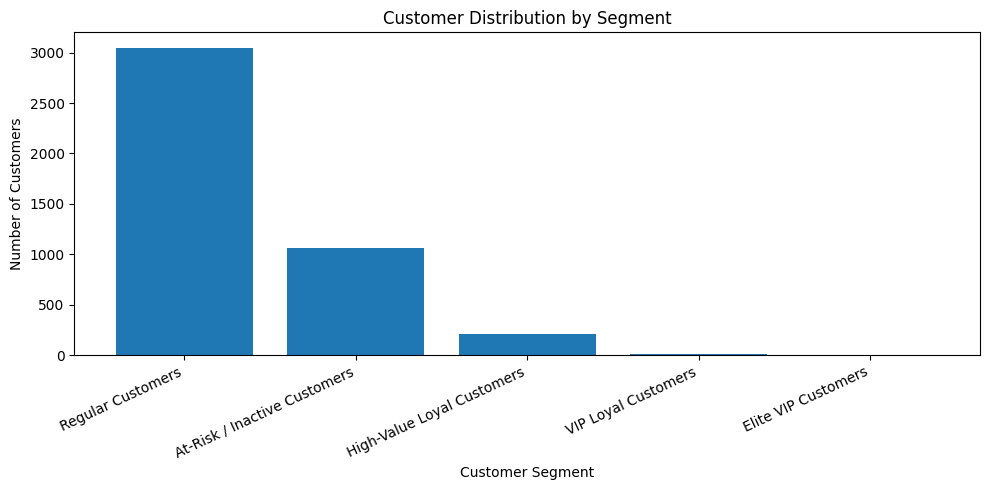

In [113]:
# Visualize customer distribution across segments
segment_plot = (
    segment_analysis
    .sort_values("Customers", ascending=False)
)

plt.figure(figsize=(10, 5))

plt.bar(
    segment_plot.index,
    segment_plot["Customers"]
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution by Segment")
plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()

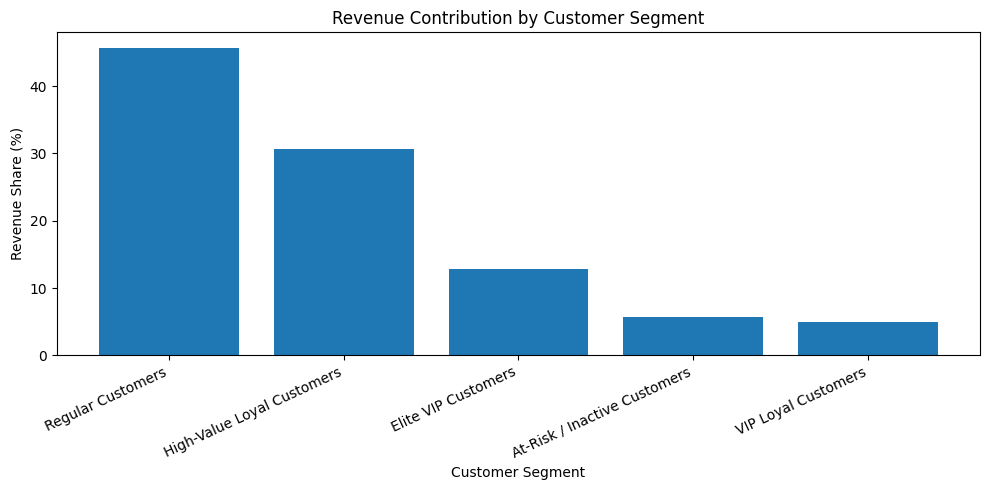

In [114]:
# Visualize revenue contribution by segment
revenue_plot = (
    segment_analysis
    .sort_values("Revenue_Share_%", ascending=False)
)

plt.figure(figsize=(10, 5))

plt.bar(
    revenue_plot.index,
    revenue_plot["Revenue_Share_%"]
)

plt.xlabel("Customer Segment")
plt.ylabel("Revenue Share (%)")
plt.title("Revenue Contribution by Customer Segment")
plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()

## 16. PCA Visualization

Principal Component Analysis was used to project the standardized RFM features into two dimensions for visualization.

The first principal component explains **55.47%** of the variance, while the second explains **30.25%**. Together, the two components explain **85.73%** of the variance in the standardized RFM features.

## Principal Component Analysis

Principal Component Analysis (PCA) was applied to the standardized RFM features to reduce the three-dimensional feature space to two dimensions for visualization. The resulting components were used to visualize the separation between customer clusters while retaining most of the variation present in the original RFM features.

In [115]:
# Reduce standardized RFM features to two principal components
pca = PCA(n_components=2)

rfm_pca = pca.fit_transform(rfm_scaled)

rfm["PC1"] = rfm_pca[:, 0]
rfm["PC2"] = rfm_pca[:, 1]

In [116]:
# Calculate explained variance
pc1_variance = pca.explained_variance_ratio_[0] * 100
pc2_variance = pca.explained_variance_ratio_[1] * 100
total_variance = pc1_variance + pc2_variance

print(f"Variance explained by PC1: {pc1_variance:.2f}%")
print(f"Variance explained by PC2: {pc2_variance:.2f}%")
print(f"Total variance explained: {total_variance:.2f}%")

Variance explained by PC1: 55.47%
Variance explained by PC2: 30.25%
Total variance explained: 85.73%


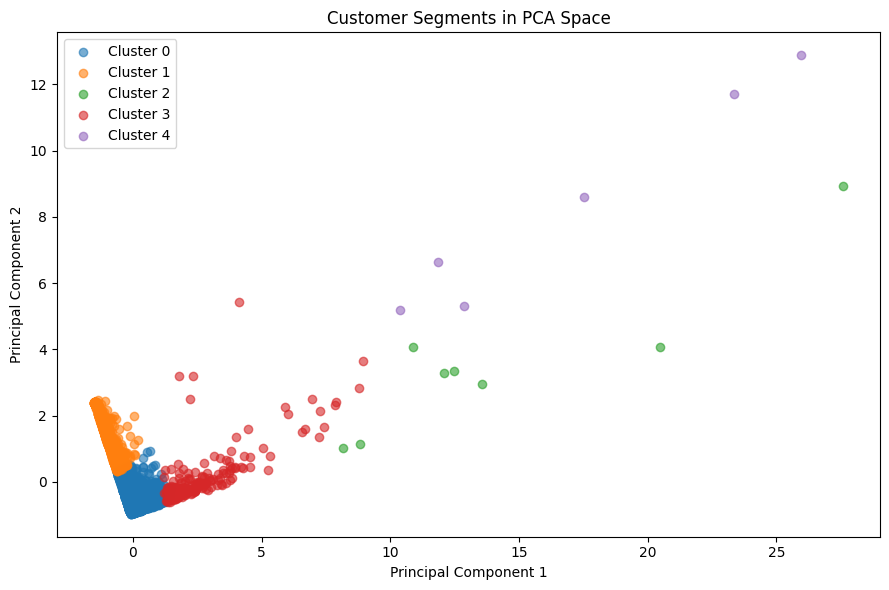

In [117]:
# Visualize customer clusters in PCA space
plt.figure(figsize=(9, 6))

for cluster in sorted(rfm["Cluster"].unique()):
    cluster_data = rfm[rfm["Cluster"] == cluster]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments in PCA Space")
plt.legend()
plt.tight_layout()
plt.show()

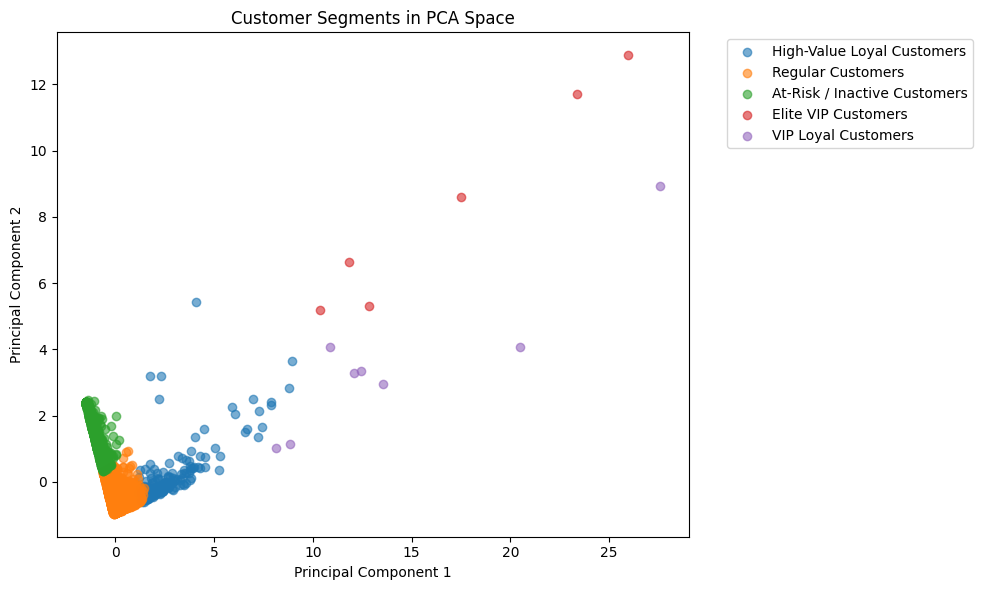

In [118]:
# Visualize business segments in PCA space
plt.figure(figsize=(10, 6))

for segment in rfm["Segment"].unique():
    segment_data = rfm[rfm["Segment"] == segment]

    plt.scatter(
        segment_data["PC1"],
        segment_data["PC2"],
        label=segment,
        alpha=0.6
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments in PCA Space")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [119]:
# Create final customer segment profile
final_segment_profile = (
    rfm.groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean"),
        Total_Revenue=("Total_Revenue", "sum")
    )
)

final_segment_profile["Customer_Share_%"] = (
    final_segment_profile["Customers"]
    / len(rfm) * 100
)

final_segment_profile["Revenue_Share_%"] = (
    final_segment_profile["Total_Revenue"]
    / final_segment_profile["Total_Revenue"].sum() * 100
)

final_segment_profile = final_segment_profile.round(2)

final_segment_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Customer_Share_%,Revenue_Share_%
Segment,,,,,,,
At-Risk / Inactive Customers,1063,248.47,1.55,478.65,508803.08,24.50,5.73
Elite VIP Customers,6,7.67,42.83,190808.54,1144851.22,0.14,12.88
High-Value Loyal Customers,213,15.67,21.29,12813.94,2729369.56,4.91,30.71
Regular Customers,3048,43.92,3.65,1333.13,4063389.10,70.26,45.72
VIP Loyal Customers,8,6.50,120.50,55099.49,440795.93,0.18,4.96


## 17. Business Recommendations

The customer segments identified through RFM-based K-Means clustering provide a basis for differentiated customer relationship and marketing strategies.

### Regular Customers

This segment represents the largest customer group, accounting for 70.26% of customers and 45.72% of revenue.

**Recommended strategy:**
- Encourage repeat purchases through personalized promotions.
- Use cross-selling and product recommendations to increase average spending.
- Identify customers showing declining purchase activity for early intervention.

### At-Risk / Inactive Customers

This group represents 24.50% of customers but contributes only 5.73% of revenue. The high recency value indicates that these customers have not purchased recently.

**Recommended strategy:**
- Launch targeted re-engagement campaigns.
- Offer time-limited incentives to encourage return purchases.
- Use personalized recommendations based on previous purchasing behaviour.
- Avoid excessive promotional spending on customers who remain unresponsive.

### High-Value Loyal Customers

Although they represent only 4.91% of customers, they contribute 30.71% of revenue.

**Recommended strategy:**
- Prioritize retention and relationship-building.
- Provide loyalty rewards and personalized offers.
- Introduce premium products and cross-selling opportunities.
- Monitor changes in their purchasing behaviour closely.

### VIP Loyal Customers

This very small group has extremely high purchase frequency and substantial monetary value.

**Recommended strategy:**
- Provide exclusive loyalty benefits.
- Offer early access to new products or promotions.
- Assign highly personalized customer engagement strategies.
- Protect these customers from service failures and dissatisfaction.

### Elite VIP Customers

This is the smallest segment but generates 12.88% of total revenue.

**Recommended strategy:**
- Treat these customers as strategically important accounts.
- Provide highly personalized service.
- Develop exclusive retention programs.
- Monitor their activity individually because losing even a small number of these customers could have a significant revenue impact.

## 19. Key Findings

The analysis identified five distinct customer segments using RFM-based K-Means clustering.

The final model achieved a Silhouette Score of 0.6165, indicating reasonably well-defined customer groupings.

The analysis revealed a highly uneven distribution of customer value. Regular Customers account for 70.26% of the customer base and generate 45.72% of revenue, while High-Value Loyal Customers represent only 4.91% of customers but contribute 30.71% of revenue.

The combined High-Value Loyal, VIP Loyal, and Elite VIP segments represent approximately 5.23% of customers while contributing approximately 48.55% of total revenue. This highlights the importance of prioritizing retention and personalized engagement for high-value customers.

At-Risk / Inactive Customers represent 24.50% of customers but contribute only 5.73% of revenue, indicating an opportunity for targeted customer reactivation strategies.

PCA showed that the first two principal components explain 85.73% of the variance in the standardized RFM features, providing a useful two-dimensional representation of the customer clusters.

In [120]:
# Save the final customer segmentation
rfm.to_csv("final_customer_segments.csv", index=False)

In [121]:
# Save the segment summary
final_segment_profile.to_csv("segment_profile.csv")

In [122]:
# Save the trained clustering model
joblib.dump(final_kmeans, "customer_segmentation_model.pkl")

['customer_segmentation_model.pkl']

In [123]:
# Save the feature scaler
joblib.dump(scaler, "rfm_scaler.pkl")

['rfm_scaler.pkl']

## Model Summary

**Dataset:** Online Retail Dataset

**Raw transaction records:** 541,909

**Cleaned transaction records:** 392,692

**Identified customers:** 4,338

**Unique invoices:** 18,532

**Clustering method:** K-Means

**Number of clusters:** 5

**Silhouette Score:** 0.6165

**RFM features:** Recency, Frequency, Monetary

**PCA variance explained:** 85.73%

**Customer segments:** Regular Customers, At-Risk / Inactive Customers, High-Value Loyal Customers, VIP Loyal Customers, and Elite VIP Customers.

## 20. Final Project Summary

In [124]:
# Verify final project outputs
print("FINAL PROJECT CHECK")
print("-" * 30)
print(f"Raw records: {len(df):,}")
print(f"Cleaned records: {len(clean_df):,}")
print(f"Customers: {rfm['CustomerID'].nunique():,}")
print(f"Clusters: {rfm['Cluster'].nunique()}")
print(f"Silhouette Score: {final_silhouette:.4f}")
print(f"PCA variance explained: {total_variance:.2f}%")
print(f"Total revenue: {rfm['Total_Revenue'].sum():,.2f}")

FINAL PROJECT CHECK
------------------------------
Raw records: 541,909
Cleaned records: 392,692
Customers: 4,338
Clusters: 5
Silhouette Score: 0.6165
PCA variance explained: 85.73%
Total revenue: 8,887,208.89


## 21. Conclusion

This project applied RFM analysis and K-Means clustering to segment customers from the Online Retail dataset according to their purchasing behaviour.

After data preprocessing, 392,692 valid transaction records representing 4,338 customers were used for the analysis. Customers were characterized using Recency, Frequency, and Monetary Value and subsequently grouped using K-Means clustering.

Five customer segments were identified: Regular Customers, At-Risk / Inactive Customers, High-Value Loyal Customers, VIP Loyal Customers, and Elite VIP Customers. The final clustering model achieved a Silhouette Score of 0.6165, indicating reasonably well-defined customer groups.

The analysis demonstrated significant differences in customer value. A small proportion of high-value customers contributed a disproportionately large share of total revenue, while a substantial proportion of customers were identified as inactive or at risk.

These findings demonstrate how customer segmentation can support targeted marketing, customer retention, loyalty management, and more efficient allocation of business resources.

In [125]:
import os
import joblib

# Create submission folders
os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

# Save the clustering model
joblib.dump(final_kmeans, "models/customer_segmentation_model.pkl")

# Save the scaler
joblib.dump(scaler, "models/rfm_scaler.pkl")

# Save customer-level segmentation results
rfm.to_csv("outputs/final_customer_segments.csv", index=False)

# Save segment summary
final_segment_profile.to_csv("outputs/segment_profile.csv")

print("Submission files created successfully.")

Submission files created successfully.


In [127]:
print("MODELS")
print(os.listdir("models"))

print("\nOUTPUTS")
print(os.listdir("outputs"))

MODELS
['customer_segmentation_model.pkl', 'rfm_scaler.pkl']

OUTPUTS
['final_customer_segments.csv', 'segment_profile.csv']
